## 9b - Run Deprivation Model with AlphaEarth Satellite Embeddings

This script:
- Reads the per-LSOA AlphaEarth embeddings (from pickle produced by script 9a)
- Selects which aggregation to use (mean, median, min, or max — all pre-computed in 9a)
- Joins with IMD deprivation data
- Fits and evaluates a regression model (XGBoost) using cross-validation with hyperparameter tuning
- Tests out-of-sample performance on a held-out 20% test set
- Saves the best model for reuse

This mirrors the methodology of **script 4** (which uses street-level CLIP embeddings)
to enable a direct comparison between street-view and satellite-derived features for
predicting area-level deprivation.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*glibc.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
import joblib
import geopandas as gpd


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from xgboost import XGBRegressor


def evaluate_imd_model(y_true, y_pred, column, num_in_class=None, num_lsoas=None,
                        plot=True, plot_collectively=False, ax=None):
    """Compute regression metrics and optionally plot true vs predicted."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Spearman_rank_corr': spearman_corr}

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel(f"True {column}")
        plt.ylabel(f"Predicted {column}")
        plt.title(f"{column}")
        plt.grid(True)
        plt.show()

    if plot_collectively and ax is not None:
        ax.scatter(y_true, y_pred, alpha=0.7)
        ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{column}: \n{num_in_class} images\n {num_lsoas} LSOAs", fontsize=15)
        ax.grid(True)
        ax.text(
            0.01, 0.99,
            f'R\u00b2 = {r2:.2f}, RMSE = {rmse:.0f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    return metrics

In [2]:
from directory_filepaths import *
from clustering_functions import RANDOM_STATE

In [3]:
# --- Configuration ---

var_to_predict = 'imd_rank'

# Which aggregation of the per-LSOA AlphaEarth embeddings to use as features.
# Script 9a pre-computes all of these: 'mean', 'median', 'min', 'max'.
# Change this and re-run to compare different aggregation strategies.
AGGREGATION = 'mean'

embedding_col = f'{AGGREGATION}_embedding'
print(f"Using '{embedding_col}' as features")

Using 'mean_embedding' as features


### Get IMD data

In [4]:
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)

# Rename columns to simpler versions
imd_col_map = {"LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile"}
imd = imd.rename(columns=imd_col_map)
imd

,LSOA21CD,LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),imd_rank,imd_decile,Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Health Deprivation and Disability Rank (where 1 is most deprived),Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,26525,8,33730,10,33708,10,33755,10,33108,10,33698,10,29220,9,244,1
1,E01000002,City of London 001B,E09000001,City of London,31203,10,33669,10,33734,10,33672,10,32574,10,33712,10,32640,10,3702,2
2,E01000003,City of London 001C,E09000001,City of London,25913,8,25167,8,26985,8,30273,9,20719,7,27325,9,30400,10,4540,2
3,E01000005,City of London 001E,E09000001,City of London,14807,5,14836,5,17911,6,15886,5,10458,4,25630,8,11294,4,5403,2
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4,7519,3,15286,5,11134,4,21901,7,17875,6,2745,1,9479,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,27536,9,25934,8,24575,8,21842,7,29534,9,13583,5,23743,8,25435,8
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,27902,9,26440,8,22891,7,25326,8,25671,8,30130,9,12406,4,28626,9
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,27532,9,18127,6,26383,8,22625,7,26857,8,19110,6,30084,9,31180,10
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,28981,9,21596,7,29547,9,24267,8,28925,9,24825,8,18053,6,29506,9


### Sanity check: map IMD rank

Quick choropleth to verify the deprivation data looks sensible
(e.g. central Manchester should be more deprived than suburban areas).

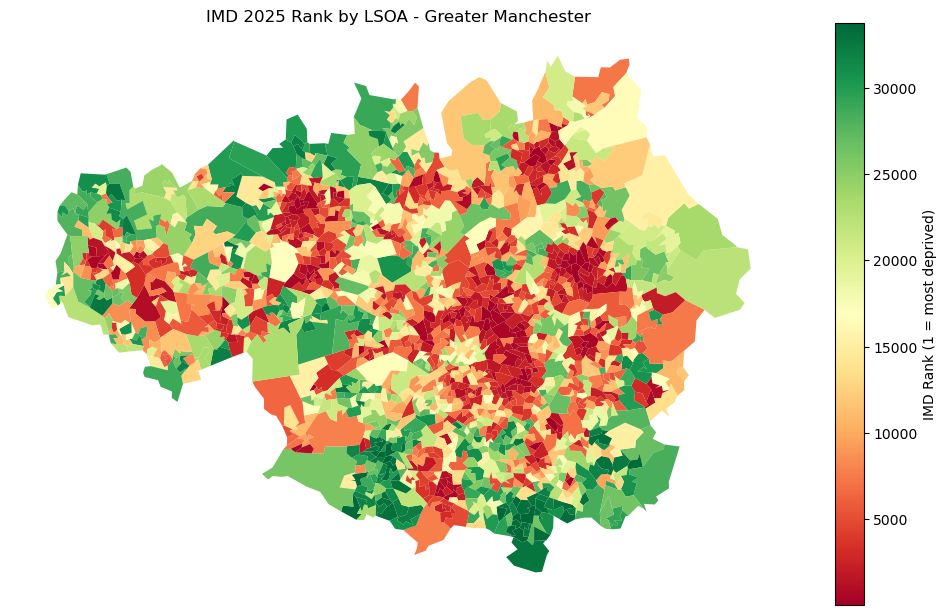

In [5]:
lsoas = gpd.read_file(lsoas_file)
manc_lads = ['Manchester', 'Rochdale', 'Bolton', 'Bury', 'Wigan', 'Oldham', 'Trafford', 'Salford', 'Tameside', 'Stockport']
gm_lsoa = lsoas[lsoas['LSOA21NM'].str.contains('|'.join(manc_lads))].to_crs(epsg=4326)

gm_lsoa_imd = gm_lsoa.merge(imd[['LSOA21CD', 'imd_rank', 'imd_decile']], on='LSOA21CD', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gm_lsoa_imd.plot(
    column='imd_rank',
    cmap='RdYlGn',  # red = low rank (most deprived), green = high rank (least deprived)
    legend=True,
    legend_kwds={'label': 'IMD Rank (1 = most deprived)', 'shrink': 0.6},
    ax=ax)
ax.set_title('IMD 2025 Rank by LSOA - Greater Manchester')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Get AlphaEarth embedding data

In [6]:
# Load the AlphaEarth embeddings pickle (produced by script 9a).
# This contains multiple aggregation columns: mean_embedding, median_embedding, min_embedding, max_embedding.
embedding_pkl = os.path.join(data_dir, "per_lsoa_embedding_summaries", "alphaearth_embeddings.pkl")
big_summary_df = pd.read_pickle(embedding_pkl)

print(f"Available aggregations: {[c for c in big_summary_df.columns if c.endswith('_embedding')]}")
print(f"Using: {embedding_col}")

big_summary_df_with_imd = pd.merge(left=big_summary_df, right=imd[['LSOA21CD', 'imd_rank']], on="LSOA21CD")
big_summary_df_with_imd['imd_rerank'] = big_summary_df_with_imd['imd_rank'].rank(method='first').astype(int)

print(f"LSOAs with both embeddings and IMD data: {len(big_summary_df_with_imd)}")
print(f"Embedding dimensionality: {len(big_summary_df_with_imd.iloc[0][embedding_col])}")

Available aggregations: ['mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding']
Using: mean_embedding
LSOAs with both embeddings and IMD data: 1702
Embedding dimensionality: 64


### Split the data into 80% training, 20% testing

Same split parameters as script 4 (`RANDOM_STATE`) to ensure comparability.

In [7]:
X = np.stack(big_summary_df_with_imd[embedding_col].values)
y = big_summary_df_with_imd[var_to_predict].values

# -------------------------
# Split data into training and test sets
# -------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, np.arange(X.shape[0]), test_size=0.2, random_state=RANDOM_STATE)
print(f"Training points: {X_train.shape[0]}, Test points: {X_test.shape[0]}")
print(f"Embedding dimensions: {X_train.shape[1]}")

Training points: 1361, Test points: 341
Embedding dimensions: 64


### Perform model selection and hyper-parameter tuning using the 80% training data

Same hyperparameter grid and cross-validation setup as script 4.

In [8]:
# Define model pipelines and parameter grids
# Each entry: (name, pipeline, param_grid)
model_configs = [
    ("XGBoost", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', XGBRegressor(
            objective='reg:squarederror',  # minimise squared error (standard for regression)
            random_state=RANDOM_STATE,               # reproducible results
            n_jobs=-1,                     # use all CPU cores for training a single model
            verbosity=0))]),               # suppress XGBoost's own logging
     {
      'reg__n_estimators': [100, 300],         # number of boosting rounds (more = more complex)
      'reg__max_depth': [3, 6, 10],            # max tree depth (controls model complexity)
      'reg__learning_rate': [0.01, 0.1, 0.3],  # step size shrinkage (lower = slower but often better)
      'reg__subsample': [0.8, 1.0],            # fraction of training rows used per tree (< 1 adds regularisation)
     }),
]

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ncores = min(multiprocessing.cpu_count() - 1, 100)

best_model = None
best_score = -np.inf
best_model_name = None
best_params = {}

print(f"Training {len(model_configs)} model(s) using {ncores} cores")

for name, pipeline, param_grid in model_configs:
    # Calculate fits for progress reporting
    n_fits = 1
    for vals in param_grid.values():
        n_fits *= len(vals)
    n_fits *= cv.n_splits
    print(f"\nTraining: {name} ({n_fits} fits)...")

    # Main grid search code:
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2', n_jobs=ncores, verbose=1)
    grid.fit(X_train, y_train)

    print(f"  CV mean R\u00b2 = {grid.best_score_:.3f}")
    print(f"  Best params: {grid.best_params_}")

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name
        best_params = grid.best_params_.copy()

print(f"\nBest model: {best_model_name} (CV R\u00b2 = {best_score:.3f})")
print(f"Best hyperparameters: {best_params}")

Training 1 model(s) using 11 cores

Training: XGBoost (180 fits)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/homebrew/anaconda3/envs/embeddings-deprivation/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV mean R² = 0.306
  Best params: {'reg__learning_rate': 0.01, 'reg__max_depth': 6, 'reg__n_estimators': 300, 'reg__subsample': 0.8}

Best model: XGBoost (CV R² = 0.306)
Best hyperparameters: {'reg__learning_rate': 0.01, 'reg__max_depth': 6, 'reg__n_estimators': 300, 'reg__subsample': 0.8}


In [9]:
# Save the best model
model_dir = os.path.join("../data/models")
os.makedirs(model_dir, exist_ok=True)

bundle = {
    "model": best_model,
    "name": best_model_name,
    "cv_score_r2": float(best_score),
    "best_params": best_params,
    "embedding_source": "alphaearth",
    "embedding_dim": X_train.shape[1],
}

model_path = os.path.join(model_dir, "best_model_alphaearth.joblib")
joblib.dump(bundle, model_path)
print(f"Saved model to {model_path}")

Saved model to ../data/models/best_model_alphaearth.joblib


## Test out-of-sample performance of 'best' model

Train on the full 80% training data, test on the 20% held-out set.

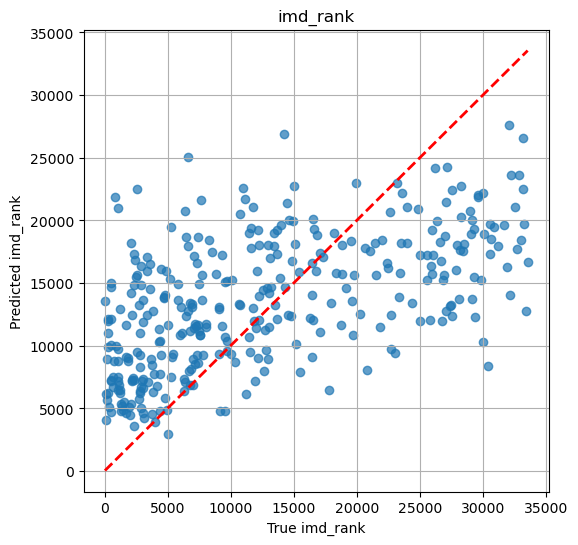

Test set metrics (AlphaEarth):
  RMSE: 8272.677
  MAE: 6839.925
  R2: 0.325
  Spearman_rank_corr: 0.594


In [10]:
# Predict on held-out test data
y_pred_test = best_model.predict(X_test)

# Evaluate using the function defined above
test_metrics = evaluate_imd_model(
    y_pred=y_pred_test,
    y_true=y_test,
    column=var_to_predict,
    plot=True)

print("Test set metrics (AlphaEarth):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")

## Compare with street-view model

Load the street-view model from script 4 and compare performance side-by-side.

In [11]:
# Load the street-view model results from script 4
sv_model_path = os.path.join("../data/models", "best_model.joblib")

if os.path.exists(sv_model_path):
    sv_bundle = joblib.load(sv_model_path)
    print("Street-view model (script 4):")
    print(f"  CV R\u00b2 = {sv_bundle['cv_score_r2']:.3f}")
    print(f"  Best params: {sv_bundle['best_params']}")
    print()
else:
    print(f"Street-view model not found at {sv_model_path}")
    print("Run script 4 first to enable comparison.")
    print()

# Compare with AlphaEarth
ae_bundle = joblib.load(os.path.join("../data/models", "best_model_alphaearth.joblib"))

print("="*60)
print("COMPARISON: Cross-validation R\u00b2")
print("="*60)
if os.path.exists(sv_model_path):
    print(f"  Street View (CLIP, 512-dim):      {sv_bundle['cv_score_r2']:.3f}")
print(f"  AlphaEarth  (satellite, 64-dim):  {ae_bundle['cv_score_r2']:.3f}")
print()
print("Test set metrics (AlphaEarth):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")

Street-view model (script 4):
  CV R² = 0.660
  Best params: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 300, 'reg__subsample': 1.0}

COMPARISON: Cross-validation R²
  Street View (CLIP, 512-dim):      0.660
  AlphaEarth  (satellite, 64-dim):  0.306

Test set metrics (AlphaEarth):
  RMSE: 8272.677
  MAE: 6839.925
  R2: 0.325
  Spearman_rank_corr: 0.594


/opt/homebrew/anaconda3/envs/embeddings-deprivation/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/anaconda3/envs/embeddings-deprivation/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Map of the residuals (true - predicted) for the AlphaEarth model across Greater Manchester LSOAs.

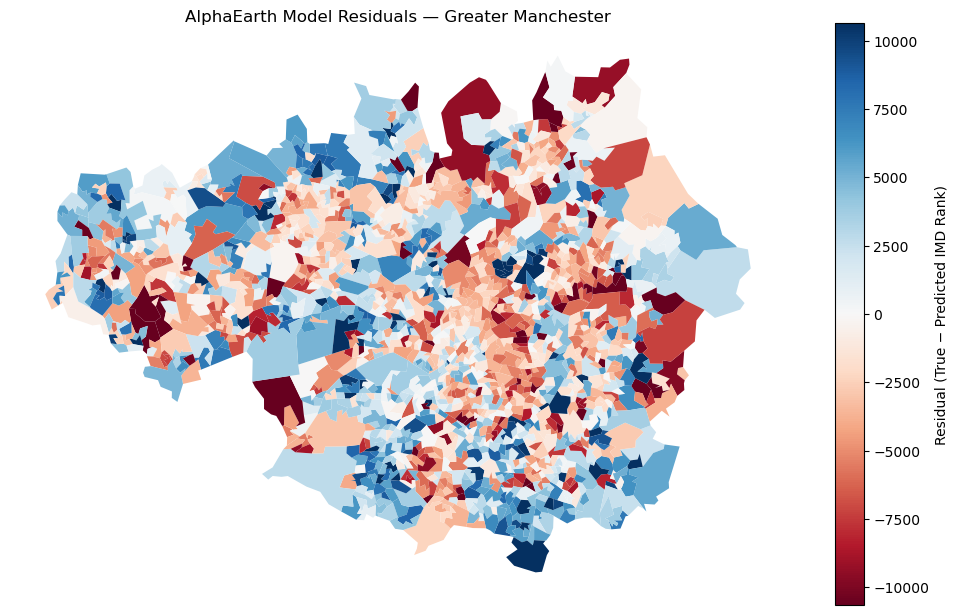

Mapped 1702 LSOAs
Mean residual: -167.0, Std: 5506.8


In [12]:
# Predict on ALL LSOAs (not just the test set) so we get a complete map
y_pred_all = best_model.predict(X)
residuals = y - y_pred_all  # positive = model under-predicted deprivation (true rank higher)

# Attach residuals to the dataframe and merge with geometries
residual_df = big_summary_df_with_imd[['LSOA21CD']].copy()
residual_df['residual'] = residuals

gm_residuals = gm_lsoa.merge(residual_df, on='LSOA21CD', how='inner')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
vmax = np.percentile(np.abs(gm_residuals['residual']), 95)  # symmetric colour scale clipped at 95th percentile
gm_residuals.plot(
    column='residual',
    cmap='RdBu',       # red = negative residual (over-predicted rank / under-predicted deprivation)
    vmin=-vmax,         # blue = positive residual (under-predicted rank / over-predicted deprivation)
    vmax=vmax,
    legend=True,
    legend_kwds={'label': 'Residual (True − Predicted IMD Rank)', 'shrink': 0.6},
    ax=ax)
ax.set_title('AlphaEarth Model Residuals — Greater Manchester')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Mapped {len(gm_residuals)} LSOAs")
print(f"Mean residual: {residuals.mean():.1f}, Std: {residuals.std():.1f}")